# charts_project.ipynb

## Проект "Дашборд конверсий"

**Цель:** построение графиков визитов и регистраций, агрегация по платформам и периодам рекламных кампаний.

**Входные данные:**
- API: визиты, регистрации
- Параметры: API_URL, DATE_BEGIN, DATE_END из .env
- CSV: ads.csv

**Выходные данные:**
- Результат обработки данных, файлы: conversion.json, ads.json
- Графики (линейные, столбчатые, с накоплением) в папке `charts`

In [44]:
import os

import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv
import plotly.express as px

### Блок: установка стилей и создание папки charts

In [24]:
sns.set(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

if not os.path.exists('./charts'):
    os.makedirs('./charts')

### Блок: запросы API и определение переменных

In [25]:
load_dotenv()
API_URL = os.getenv('API_URL')
DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')

### Блок: загрузка данных

In [26]:
visits_url = f"{API_URL}/visits?begin={DATE_BEGIN}&end={DATE_END}"
regs_url = f"{API_URL}/registrations?begin={DATE_BEGIN}&end={DATE_END}"
visits_df = pd.DataFrame(requests.get(visits_url).json())
regs_df = pd.DataFrame(requests.get(regs_url).json())

### Блок: приведение 'date' к типу datetime

In [27]:
visits_df['date'] = pd.to_datetime(visits_df['datetime']).dt.date
regs_df["date"] = pd.to_datetime(regs_df["datetime"]).dt.date

### Блок: удаление записей содержащих 'bot' и удаление дубликатов

In [28]:
visits_df = visits_df[~visits_df["user_agent"].str.contains("bot", case=False, na=False)]
visits_df = visits_df.sort_values("datetime").drop_duplicates("visit_id", keep="last")

### Блок: группировки данных

In [29]:
visits_grouped = visits_df.groupby(["date", "platform"]).size().reset_index(name="visits")
regs_grouped = regs_df.groupby(["date", "platform"]).size().reset_index(name="registrations")

### Блок: объединения данных визитов и регистраций

In [30]:
merged_df = pd.merge(
    visits_grouped, 
    regs_grouped, 
    on=["date", "platform"], 
    how="outer"
)
merged_df["visits"] = merged_df["visits"].fillna(0).astype(int)
merged_df["registrations"] = merged_df["registrations"].fillna(0).astype(int)
merged_df["conversion"] = merged_df.apply(
    lambda row: (row["registrations"] / row["visits"] * 100) if row["visits"] > 0 else 0, axis=1
)
merged_df = merged_df.sort_values("date")

### Блок: финальная конверсия

In [31]:
conversion = merged_df.rename(columns={"date": "date_group"})[["date_group", "platform", "visits", "registrations", "conversion"]]
conversion.to_json("conversion.json", orient="columns")

### Блок: парсинг ads.csv 

In [32]:
ads_df = pd.read_csv("ads.csv")
ads_df["date"] = pd.to_datetime(ads_df["date"]).dt.date
ads_df["cost"] = pd.to_numeric(ads_df["cost"], errors="coerce").fillna(0)
ads_grouped = ads_df.groupby(["date", "utm_campaign"]).agg(cost=("cost", "sum")).reset_index()

### Блок: слияние визитов, регистрации, ads

In [33]:
ads_merged = pd.merge(merged_df, ads_grouped, on="date", how="left").fillna(0)
ads_merged.to_json("ads.json", orient="columns")

### Визуализация
- [Итоговые визиты]()
- [Итоговые визиты с разбивкой по платформам]()
- [Итоговые регистрации]()
- [Итоговые регистрации с разбивкой по платформе]()
- [Конверсия по каждой платформе]()
- [Итоговые конверсии]()
- [Стоимости реклам]()
- [Визиты и регистрации с выделением рекламных кампаний]()

### Итоговые визиты

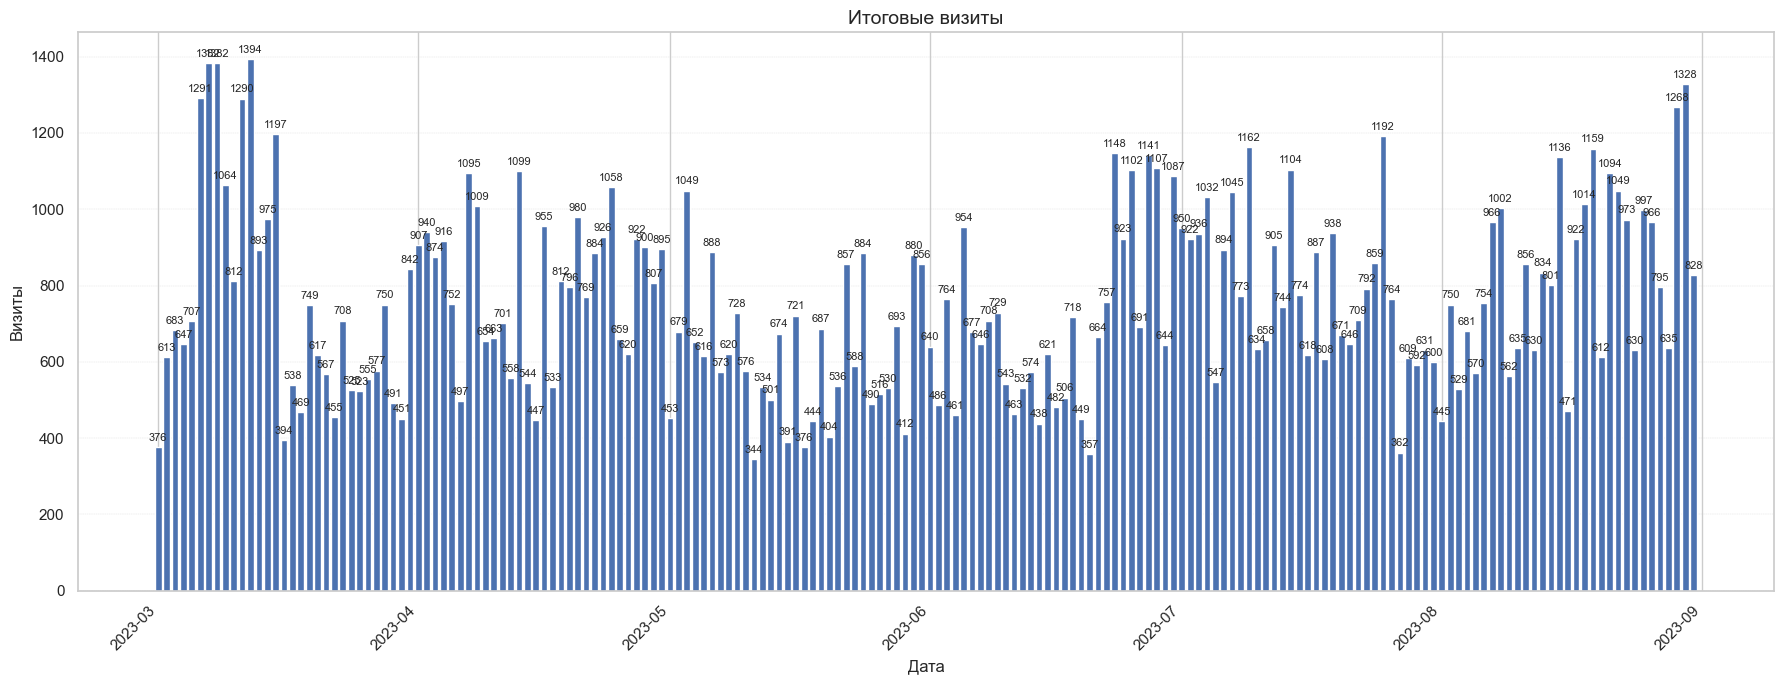

In [34]:
daily_visits = (merged_df
                .groupby('date', as_index=False)['visits']
                .sum()
                .sort_values('date'))
fig, ax = plt.subplots(figsize=(18, 7))
bars = ax.bar(daily_visits['date'],
              daily_visits['visits'])

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=8)

ax.set_title('Итоговые визиты', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Визиты')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.7)

plt.tight_layout()
plt.savefig('./charts/total_visits.png')

### Итоговые визиты с разбивкой по платформам

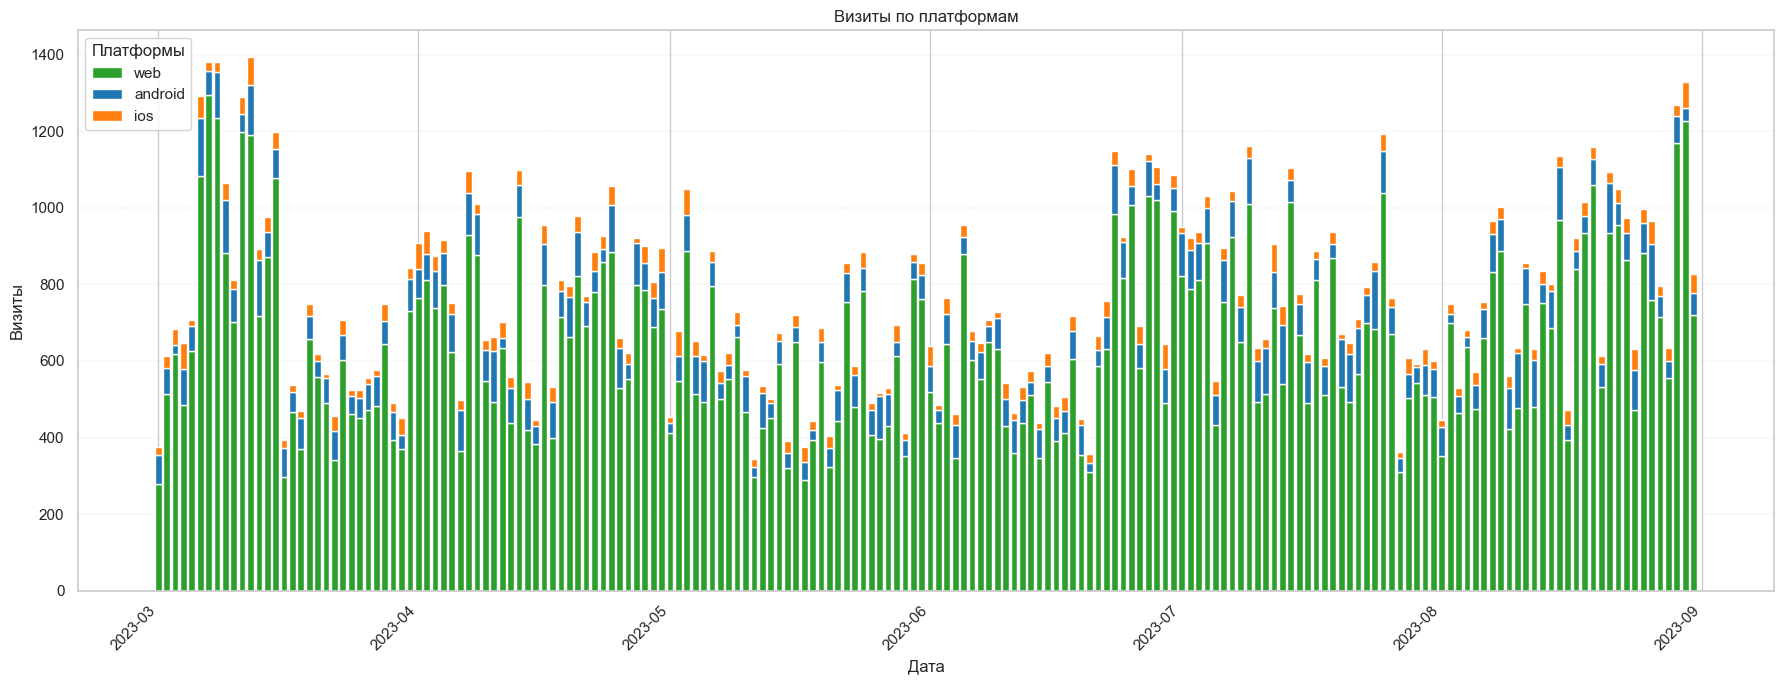

In [35]:
conversion['date_group'] = pd.to_datetime(conversion['date_group'])

pivot = (conversion.pivot_table(index='date_group',
                      columns='platform',
                      values='visits',
                      aggfunc='sum')
         .fillna(0)
         .sort_index())
pivot = pivot.reindex(columns=['web', 'android', 'ios'])

fig, ax = plt.subplots(figsize=(18, 7))

bottom = np.zeros(len(pivot))
colors = {'web':   '#2ca02c',
          'android': '#1f77b4',
          'ios':    '#ff7f0e'}

for platform in pivot.columns:
    ax.bar(pivot.index,
           pivot[platform],
           bottom=bottom,
           label=platform,
           color=colors.get(platform))
    bottom += pivot[platform].values

plt.xticks(rotation=45, ha='right')

ax.set_title('Визиты по платформам')
ax.set_xlabel('Дата')
ax.set_ylabel('Визиты')
ax.legend(title='Платформы')
ax.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.savefig('./charts/Visits_by_platform.png')
plt.tight_layout()
plt.show()

### Итоговые регистрации

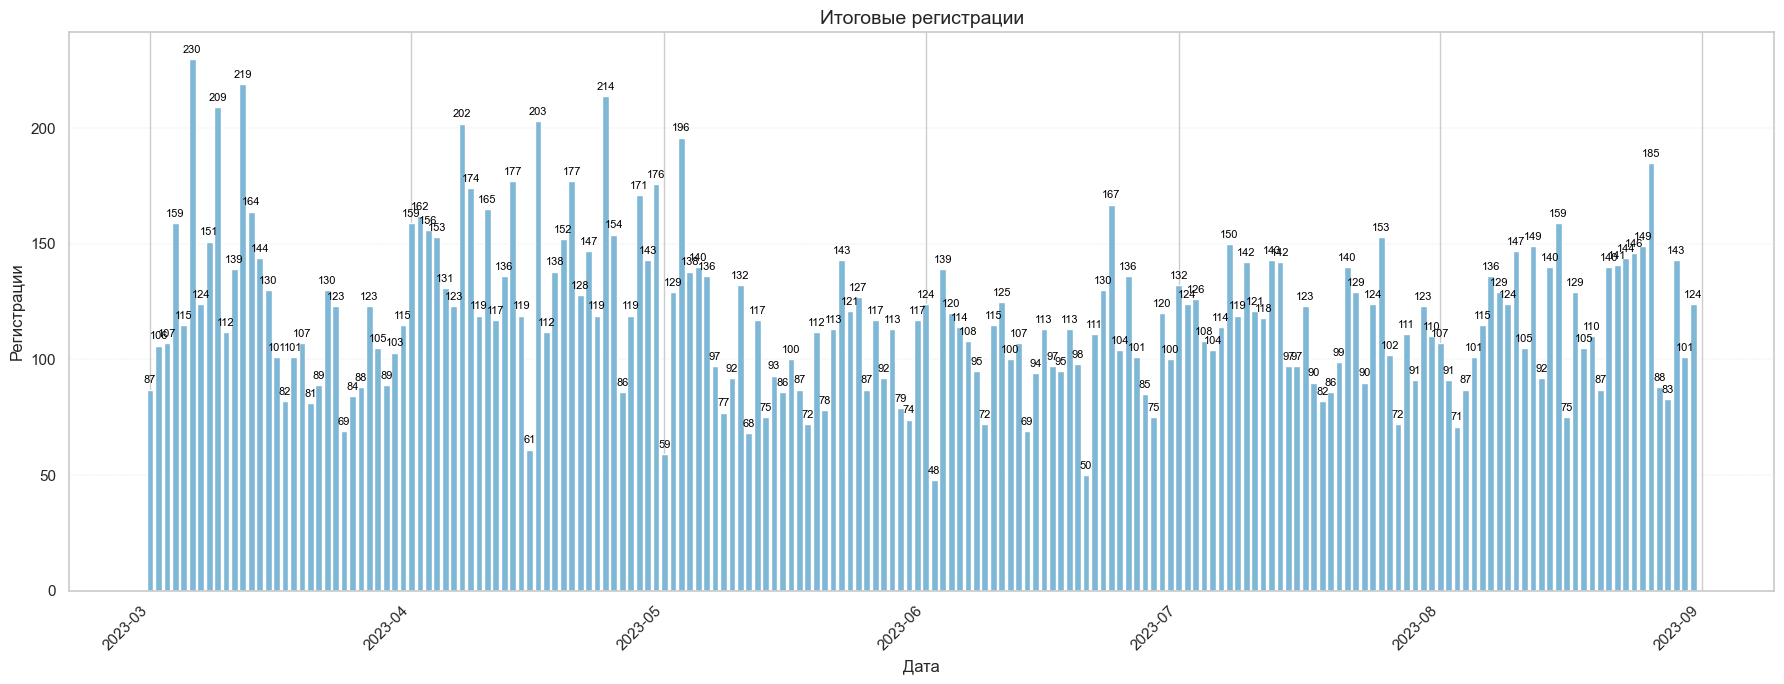

In [36]:
merged_df['date'] = pd.to_datetime(merged_df['date'])
daily_regs = (
    merged_df
    .groupby('date', as_index=False)['registrations']
    .sum()
    .sort_values('date')
)
fig, ax = plt.subplots(figsize=(18, 7))
bars = ax.bar(daily_regs['date'],
              daily_regs['registrations'],
              color='#7fb8d6')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=8, color='black')

ax.set_title('Итоговые регистрации', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Регистрации')

plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.savefig('./charts/total_registrations.png')
plt.tight_layout()
plt.show()

### Итоговые регистрации с разбивкой по платформам

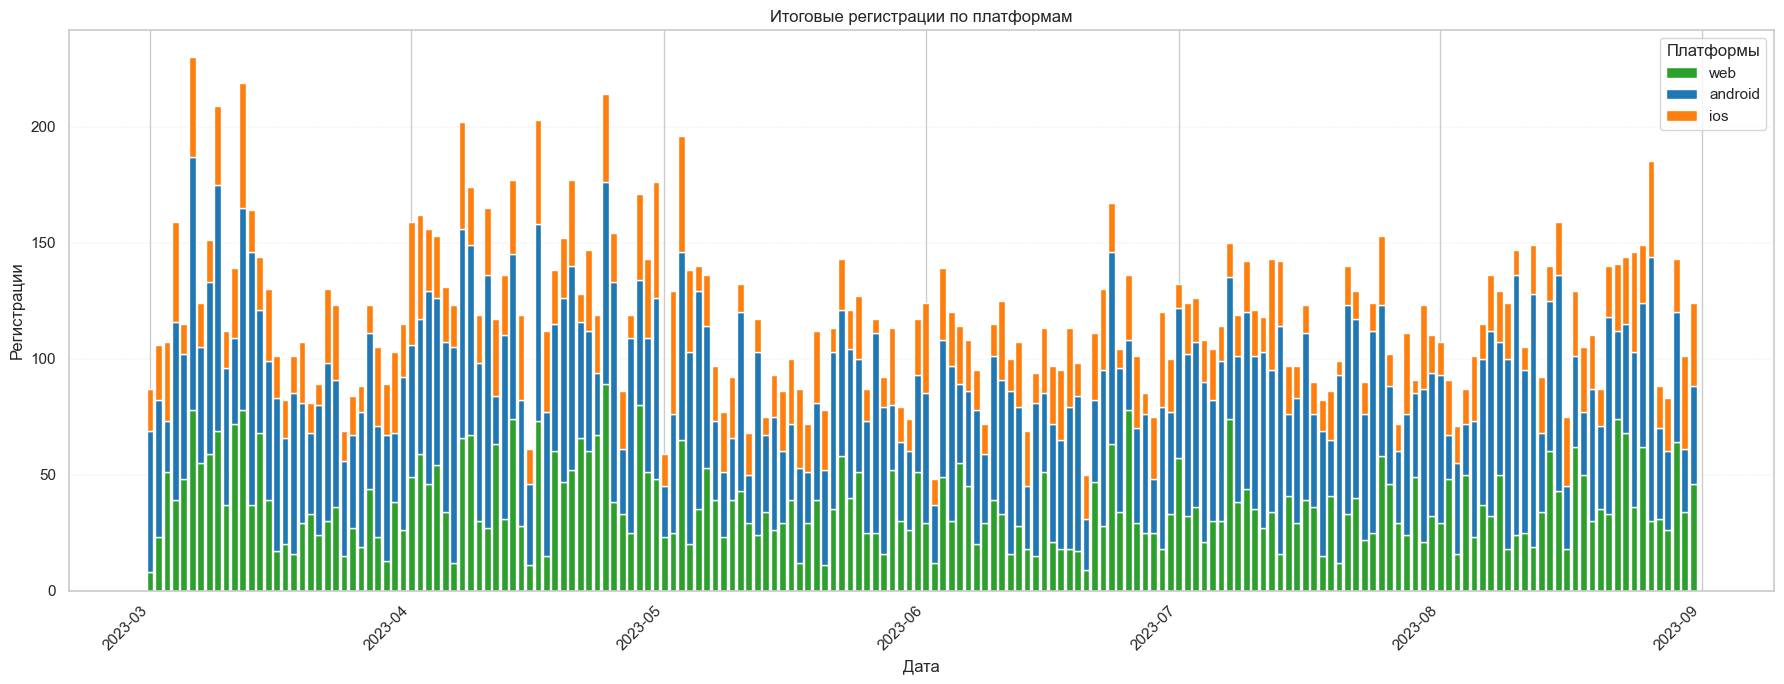

In [37]:
pivot_regs = (conversion.pivot_table(index='date_group',
                           columns='platform',
                           values='registrations',
                           aggfunc='sum')
              .fillna(0)
              .sort_index())

pivot_regs = pivot_regs.reindex(columns=['web', 'android', 'ios'])

fig, ax = plt.subplots(figsize=(18, 7))

bottom = np.zeros(len(pivot_regs))
palette = {'web':     '#2ca02c',
           'android': '#1f77b4',
           'ios':     '#ff7f0e'}

for platform in pivot_regs.columns:
    ax.bar(pivot_regs.index,
           pivot_regs[platform],
           bottom=bottom,
           label=platform,
           color=palette.get(platform))
    bottom += pivot_regs[platform].values

plt.xticks(rotation=45, ha='right')

ax.set_title('Итоговые регистрации по платформам')
ax.set_xlabel('Дата')
ax.set_ylabel('Регистрации')
ax.legend(title='Платформы')
ax.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.savefig('./charts/regs_by_platform.png')
plt.tight_layout()
plt.show()

### Конверсии по каждой платформе

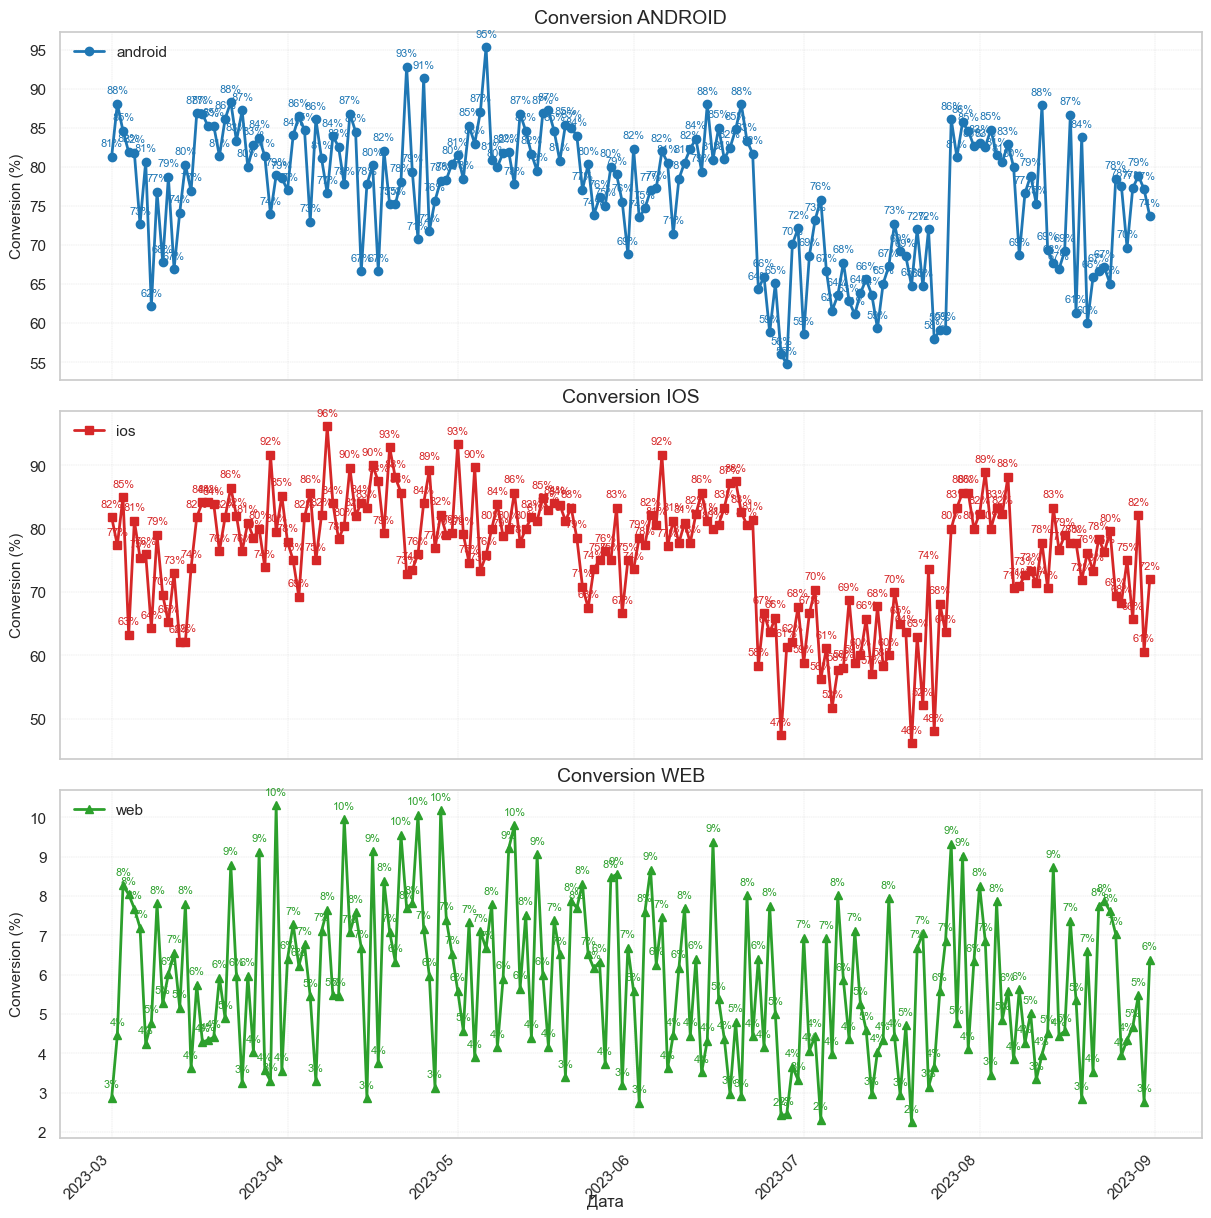

In [49]:
conv_daily = (conversion.groupby(['date_group', 'platform'], as_index=False)['conversion']
              .mean())
platform_order = ['android', 'ios', 'web']

platform_style = {
    "android": {"color": "#1f77b4", "marker": "o"}, 
    "ios":     {"color": "#d62728", "marker": "s"}, 
    "web":     {"color": "#2ca02c", "marker": "^"}, 
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 12),
    sharex=True,
    constrained_layout=True
)

for ax, plat in zip(axes, platform_order):
    data = conv_daily[conv_daily["platform"] == plat].sort_values("date_group")
    style = platform_style[plat]

    ax.plot(
        data["date_group"],
        data["conversion"],
        marker=style["marker"],
        linestyle="-",
        color=style["color"],
        label=plat,
        linewidth=2,
        markersize=6
    )
    for x, y in zip(data["date_group"], data["conversion"]):
        ax.annotate(
            f"{y:.0f}%",
            xy=(x, y),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            va="bottom",
            fontsize=8,
            color=style["color"]
        )

    ax.set_title(f"Conversion {plat.upper()}", fontsize=14)
    ax.set_ylabel("Conversion (%)", fontsize=11)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.7)
    ax.legend(loc="upper left", frameon=False)
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
fig.text(0.5, 0, "Дата", ha="center", fontsize=12)
plt.savefig('./charts/overall_conversion.png')
plt.show()

### Итоговые конверсии

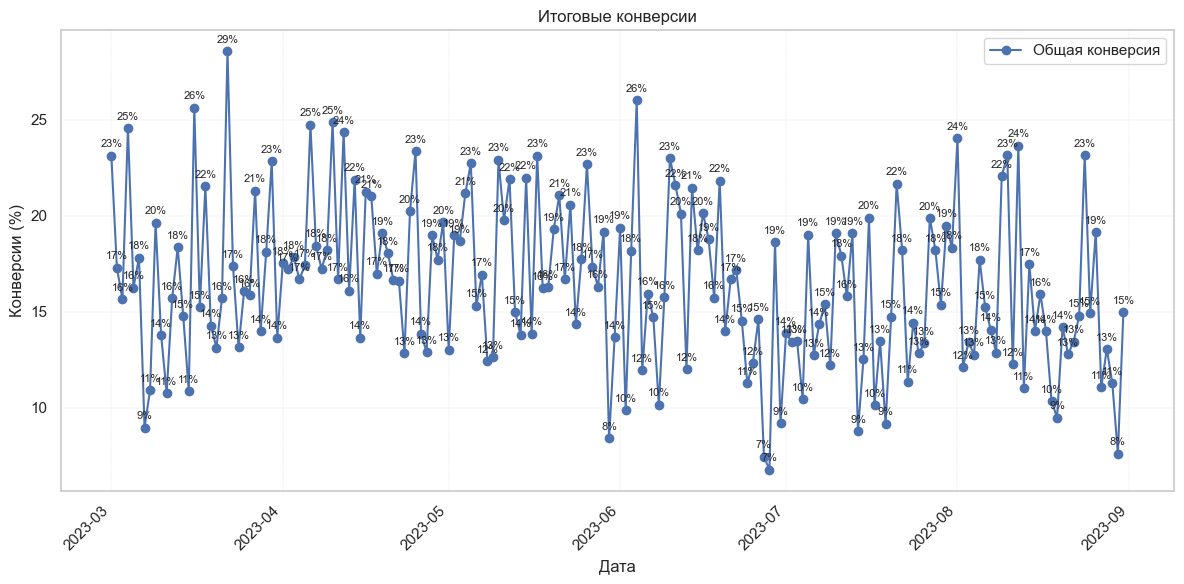

In [39]:
merged_df['date'] = pd.to_datetime(merged_df['date'])
daily_totals = (merged_df
                .groupby('date', as_index=False)
                .agg({'visits': 'sum', 'registrations': 'sum'})
                .sort_values('date'))
daily_totals['conversion'] = (daily_totals['registrations']
                              / daily_totals['visits'] * 100)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_totals['date'],
        daily_totals['conversion'],
        marker='o',
        linestyle='-',
        label='Общая конверсия')

for x, y in zip(daily_totals['date'], daily_totals['conversion']):
    ax.annotate(f'{y:.0f}%', (x, y),
                textcoords='offset points',
                xytext=(0, 6),
                ha='center',
                fontsize=8)

ax.set_title('Итоговые конверсии')
ax.set_xlabel('Дата')
ax.set_ylabel('Конверсии (%)')
ax.legend()

plt.xticks(rotation=45, ha='right')

ax.grid(True, linestyle='--', linewidth=0.3, alpha=0.7)
plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')
plt.show()

### Визиты и регистрации во время рекламных компаний

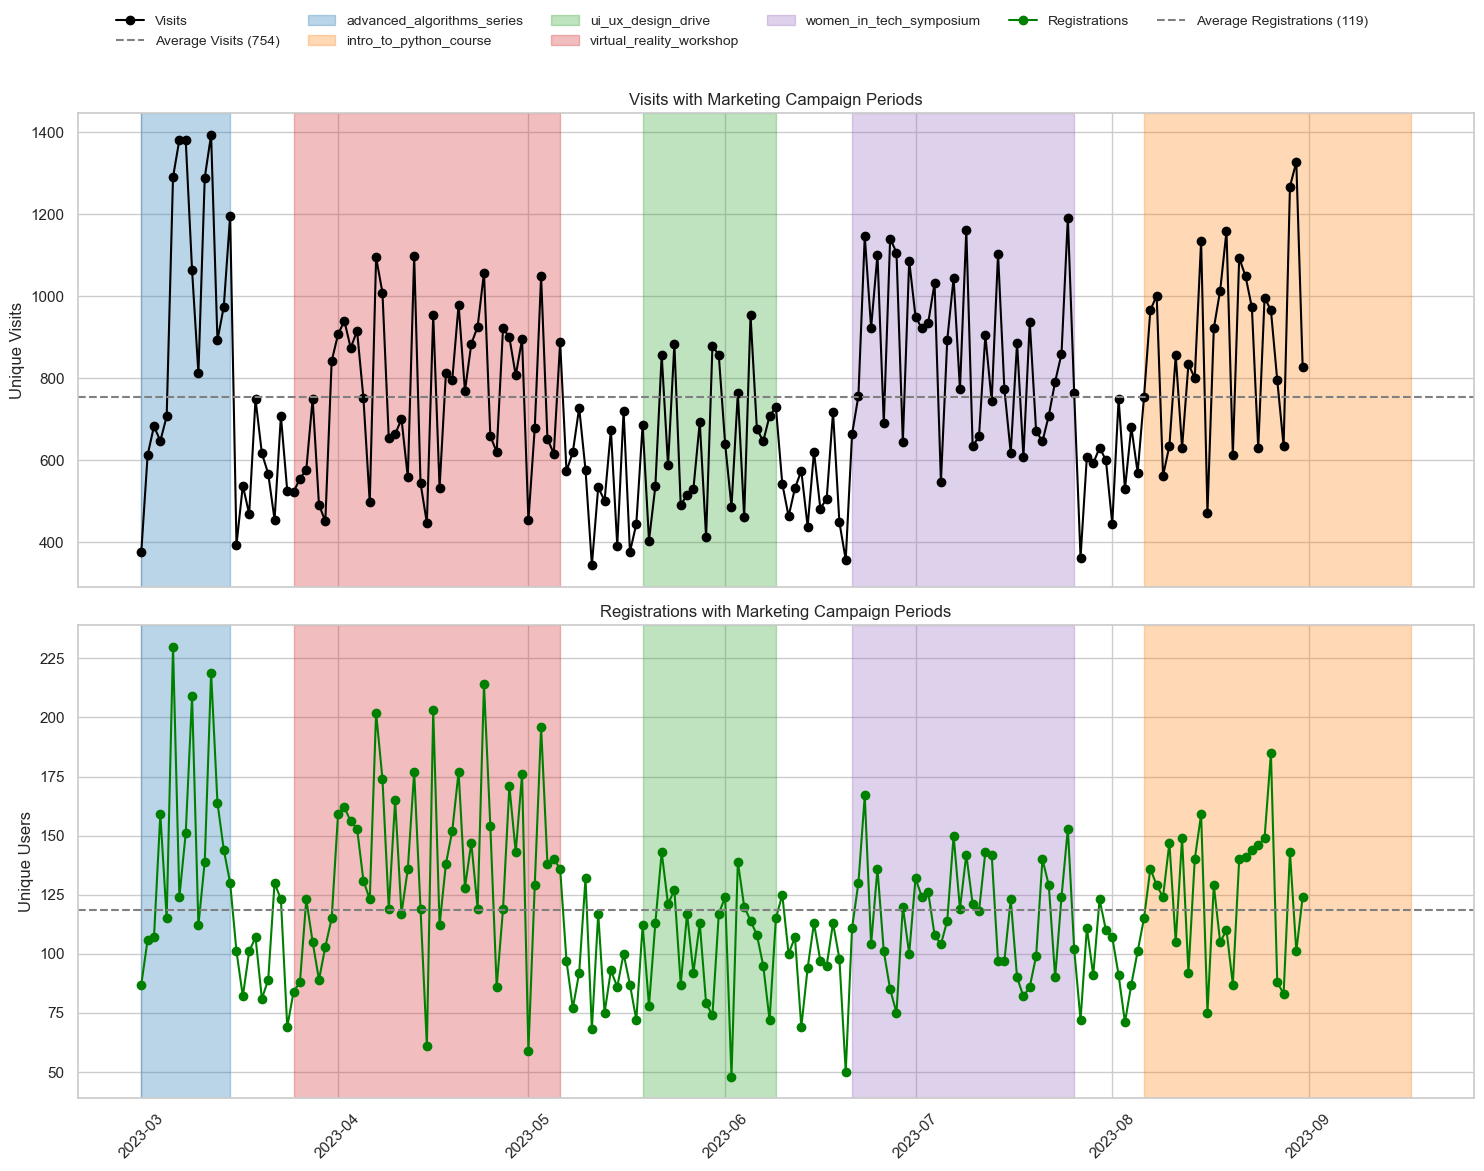

In [50]:
daily = merged_df.groupby('date').agg({
    'visits': 'sum',
    'registrations': 'sum'
}).reset_index()

campaigns = ads_df.groupby('utm_campaign').agg(
    start=('date', 'min'),
    end=('date', 'max')
).reset_index()

daily['date'] = daily['date'].astype('datetime64[ns]')
campaigns[['start', 'end']] = campaigns[['start', 'end']].astype('datetime64[ns]')

unique_campaigns = campaigns['utm_campaign'].unique()
colors = plt.cm.tab10(range(len(unique_campaigns)))
color_map = {camp: colors[i] for i, camp in enumerate(unique_campaigns)}

fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

mean_visits = daily['visits'].mean()
mean_regs = daily['registrations'].mean()

ax[0].plot(daily['date'], daily['visits'], '-o', color='black', label='Visits')

avg_label_visits = f'Average Visits ({mean_visits:.0f})'
ax[0].axhline(mean_visits, color='gray', linestyle='--', label=avg_label_visits)

for _, row in campaigns.iterrows():
    camp = row['utm_campaign']
    ax[0].axvspan(row['start'], row['end'],
                  color=color_map[camp],
                  alpha=0.3,
                  label=camp)

ax[0].set_ylabel('Unique Visits')
ax[0].set_title('Visits with Marketing Campaign Periods')

ax[1].plot(daily['date'], daily['registrations'], '-o', color='green', label='Registrations')

avg_label_regs = f'Average Registrations ({mean_regs:.0f})'
ax[1].axhline(mean_regs, color='gray', linestyle='--', label=avg_label_regs)

for _, row in campaigns.iterrows():
    camp = row['utm_campaign']
    ax[1].axvspan(row['start'], row['end'],
                  color=color_map[camp],
                  alpha=0.3,
                  label=None) 

ax[1].set_ylabel('Unique Users')
ax[1].set_title('Registrations with Marketing Campaign Periods')

plt.xticks(rotation=45)

all_handles = []
all_labels = []

for axis in ax:
    handles, labels = axis.get_legend_handles_labels()
    all_handles.extend(handles)
    all_labels.extend(labels)

by_label = {}
for h, l in zip(all_handles, all_labels):
    if l not in by_label:
        by_label[l] = h

final_handles = list(by_label.values())
final_labels = list(by_label.keys())

fig.legend(
    final_handles,
    final_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=min(len(final_labels), 6),
    fontsize=10,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('./charts/visits_and_regs.png', dpi=300)
plt.show()